In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Project root:", os.getcwd())

Project root: C:\Users\user\Desktop\Plant_Stress_Domain_Shift


In [2]:
combined_path = "results/mobilenetv3_small_performance_uncertainty_summary.csv"

combined_results = pd.read_csv(combined_path)

print(combined_results)

  train_dataset             test_dataset              model  accuracy  \
0  PlantVillage  PlantVillage_validation  MobileNetV3-Small  0.962500   
1  PlantVillage                 PlantDoc  MobileNetV3-Small  0.744168   
2  PlantVillage       PlantPathology2020  MobileNetV3-Small  0.734212   

   precision   recall  f1_score   roc_auc  brier_score       ece  
0   1.000000  0.92500  0.961039  0.997075     0.029081  0.012496  
1   0.752963  0.92058  0.828378  0.718911     0.216671  0.175521  
2   0.807031  0.82682  0.816805  0.723522     0.202652  0.143595  


In [3]:
pv_cm = pd.read_csv(
    "results/mobilenetv3_small_plantvillage_validation_confusion_matrix.csv",
    index_col=0
)

plantdoc_cm = pd.read_csv(
    "results/mobilenetv3_small_cross_dataset_plantdoc_confusion_matrix.csv",
    index_col=0
)

pp2020_cm = pd.read_csv(
    "results/mobilenetv3_small_cross_dataset_plantpathology2020_confusion_matrix.csv",
    index_col=0
)

print("PlantVillage validation confusion matrix:")
print(pv_cm)

print("\nPlantDoc confusion matrix:")
print(plantdoc_cm)

print("\nPlant Pathology 2020 confusion matrix:")
print(pp2020_cm)

PlantVillage validation confusion matrix:
                        Predicted Healthy  Predicted Stressed/Diseased
True Healthy                          200                            0
True Stressed/Diseased                 15                          185

PlantDoc confusion matrix:
                        Predicted Healthy  Predicted Stressed/Diseased
True Healthy                          326                          521
True Stressed/Diseased                137                         1588

Plant Pathology 2020 confusion matrix:
                        Predicted Healthy  Predicted Stressed/Diseased
True Healthy                          258                          258
True Stressed/Diseased                226                         1079


In [4]:
decision_errors = pd.DataFrame([
    {
        "test_dataset": "PlantVillage_validation",
        "false_alarms": pv_cm.loc["True Healthy", "Predicted Stressed/Diseased"],
        "missed_detections": pv_cm.loc["True Stressed/Diseased", "Predicted Healthy"]
    },
    {
        "test_dataset": "PlantDoc",
        "false_alarms": plantdoc_cm.loc["True Healthy", "Predicted Stressed/Diseased"],
        "missed_detections": plantdoc_cm.loc["True Stressed/Diseased", "Predicted Healthy"]
    },
    {
        "test_dataset": "PlantPathology2020",
        "false_alarms": pp2020_cm.loc["True Healthy", "Predicted Stressed/Diseased"],
        "missed_detections": pp2020_cm.loc["True Stressed/Diseased", "Predicted Healthy"]
    }
])

print(decision_errors)

              test_dataset  false_alarms  missed_detections
0  PlantVillage_validation             0                 15
1                 PlantDoc           521                137
2       PlantPathology2020           258                226


In [5]:
decision_errors["decision_cost"] = (
    decision_errors["false_alarms"] * 1 +
    decision_errors["missed_detections"] * 3
)

print(decision_errors)

              test_dataset  false_alarms  missed_detections  decision_cost
0  PlantVillage_validation             0                 15             45
1                 PlantDoc           521                137            932
2       PlantPathology2020           258                226            936


In [6]:
decision_path = "results/mobilenetv3_small_decision_error_costs.csv"

decision_errors.to_csv(decision_path, index=False)

print("Decision error costs saved at:", decision_path)
print(decision_errors)

Decision error costs saved at: results/mobilenetv3_small_decision_error_costs.csv
              test_dataset  false_alarms  missed_detections  decision_cost
0  PlantVillage_validation             0                 15             45
1                 PlantDoc           521                137            932
2       PlantPathology2020           258                226            936


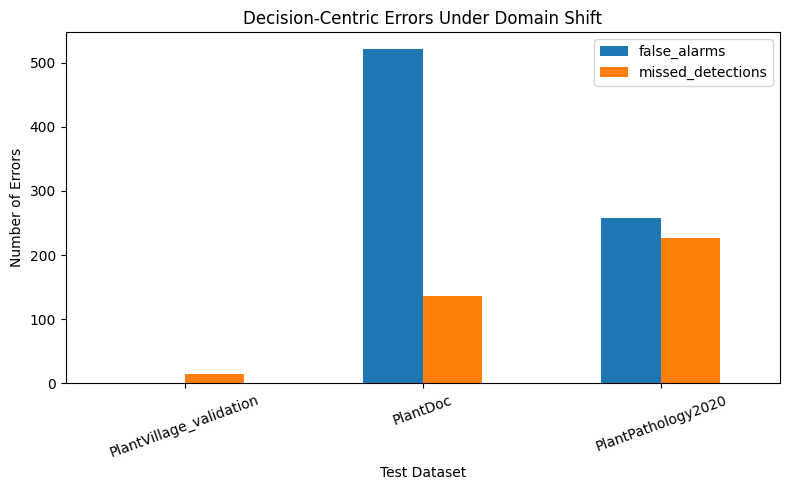

Figure saved at: results/mobilenetv3_small_decision_errors.png


In [7]:
plot_errors = decision_errors.set_index("test_dataset")[["false_alarms", "missed_detections"]]

plot_errors.plot(kind="bar", figsize=(8, 5))

plt.title("Decision-Centric Errors Under Domain Shift")
plt.xlabel("Test Dataset")
plt.ylabel("Number of Errors")
plt.xticks(rotation=20)
plt.tight_layout()

figure_path = "results/mobilenetv3_small_decision_errors.png"
plt.savefig(figure_path, dpi=300)

plt.show()

print("Figure saved at:", figure_path)

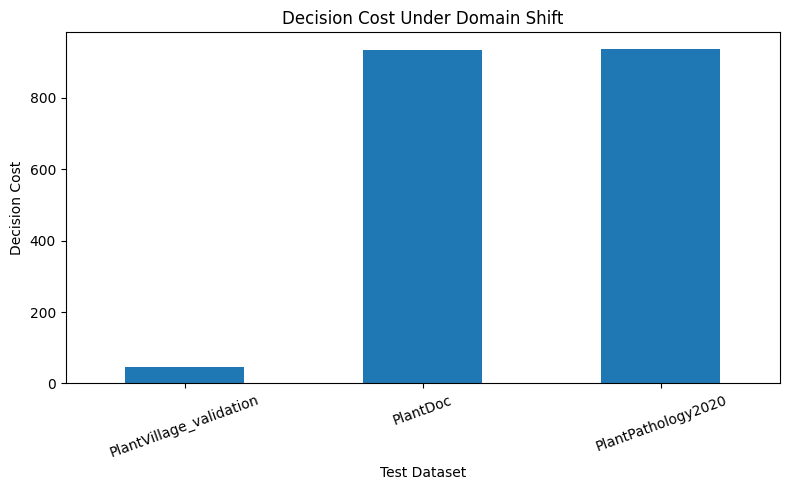

Figure saved at: results/mobilenetv3_small_decision_cost.png


In [8]:
cost_plot = decision_errors.set_index("test_dataset")[["decision_cost"]]

cost_plot.plot(kind="bar", figsize=(8, 5), legend=False)

plt.title("Decision Cost Under Domain Shift")
plt.xlabel("Test Dataset")
plt.ylabel("Decision Cost")
plt.xticks(rotation=20)
plt.tight_layout()

figure_path = "results/mobilenetv3_small_decision_cost.png"
plt.savefig(figure_path, dpi=300)

plt.show()

print("Figure saved at:", figure_path)

In [9]:
decision_uncertainty_summary = combined_results.merge(
    decision_errors,
    on="test_dataset",
    how="left"
)

output_path = "results/mobilenetv3_small_decision_uncertainty_summary.csv"

decision_uncertainty_summary.to_csv(output_path, index=False)

print("Decision + uncertainty summary saved at:", output_path)
print(decision_uncertainty_summary)

Decision + uncertainty summary saved at: results/mobilenetv3_small_decision_uncertainty_summary.csv
  train_dataset             test_dataset              model  accuracy  \
0  PlantVillage  PlantVillage_validation  MobileNetV3-Small  0.962500   
1  PlantVillage                 PlantDoc  MobileNetV3-Small  0.744168   
2  PlantVillage       PlantPathology2020  MobileNetV3-Small  0.734212   

   precision   recall  f1_score   roc_auc  brier_score       ece  \
0   1.000000  0.92500  0.961039  0.997075     0.029081  0.012496   
1   0.752963  0.92058  0.828378  0.718911     0.216671  0.175521   
2   0.807031  0.82682  0.816805  0.723522     0.202652  0.143595   

   false_alarms  missed_detections  decision_cost  
0             0                 15             45  
1           521                137            932  
2           258                226            936  
